# Simple visualisation of learned potential

In [4]:
import os
if 'LD_LIBRARY_PATH' in os.environ:
    del os.environ['LD_LIBRARY_PATH']

os.environ['JAX_PLATFORMS'] = ''

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np
from tqdm.notebook import tqdm

## Load model

In [47]:
from omegaconf import OmegaConf
# from polymer_dynamics_wi import build_model
from polymer_dynamics_wi_symm import build_model


# path = "outputs/2025_09_13-21_40_00"  # Fully symmetrised PCA and model, run 1
# path = "outputs/2025_09_13-21_39_48"  # Fully symmetrised PCA and model, run 2

# path = "outputs/2025_09_16-09_46_47" # Fully symmetrised PCA and model, with log-scale F, run 1
# path = "outputs/2025_09_16-09_46_52" # Fully symmetrised PCA and model, with log-scale F, run 1

# path = "outputs/2025_09_20-16_07_22"   # Fully symmetrised PCA and model, log-scale, extra data, run 1
# path = "outputs/2025_09_21-10_13_21"   # Fully symmetrised PCA and model, log-scale, extra data, run 2
# path = "outputs/2025_09_21-10_15_54"   # Fully symmetrised PCA and model, log-scale, extra data, run 3
# path = "outputs/2025_09_21-10_14_45"   # Fully symmetrised PCA and model, log-scale, extra data, run 4
# path = "outputs/2025_09_21-10_16_23"   # Fully symmetrised PCA and model, log-scale, extra data, run 5

# path = "outputs/2025_09_24-21_15_29" # New everything, norm constrained on M and W


# path = "outputs/2025_09_25-20_02_34"  # New everything, no norm constraint, regularisation, run1
# path = "outputs/2025_09_26-21_42_14"
# path = "outputs/2025_09_26-21_42_02"

path = "outputs/2025_09_28-21_33_12"  # new everything, no norm constraint, regularisation (1e-3), run 1
# path = "outputs/2025_09_28-21_33_17"




config = OmegaConf.load(os.path.join(path, ".hydra/config.yaml"))
model_template = build_model(config)
trained_model = eqx.tree_deserialise_leaves(os.path.join(path, "model.eqx"), model_template)

# SCRATCH

## Build potential function

In [48]:
@jax.jit
def V(z1, z2, z3, T, F):  # V no longer depends on T
    args = jnp.array([T, F])
    coords = jnp.array([z1, z2, z3])
    return trained_model.potential(coords, args)

## Visualisation of the potential

In [49]:
z1_min, z1_max = -0.5, 1.5
z2_min, z2_max = -3, 3
z3_min, z3_max = -3, 3
num_samples_aux_dimension = 128  # number of samples to take infimum over

@jax.jit
def V_12(z1, z2, T, F):
    z3_test_range = jnp.linspace(z3_min, z3_max, num_samples_aux_dimension)
    return jnp.min(jax.vmap(V, (None, None, 0, None, None))(z1, z2, z3_test_range, T, F))

In [ ]:
from ipywidgets import interact, FloatSlider

num_grid = 100
num_levels = 256
level_start = 0
level_end = 120.0
custom_levels = jnp.linspace(level_start, level_end, num_levels)

F_min = -2.0
F_max = 1.0
F_step = 0.1

def get_V_12(T, F):
    z1_range = jnp.linspace(z1_min, z1_max, num_grid)
    z2_range = jnp.linspace(z2_min, z2_max, num_grid)
    Z1, Z2 = jnp.meshgrid(z1_range, z2_range)
    V12_grid = jax.vmap(V_12, in_axes=(0, 0, None, None))(Z1.ravel(), Z2.ravel(), T, F).reshape(Z1.shape)
    return Z1, Z2, V12_grid


def plot_potential_contour(T, F):
    # Get the Z1, Z2 meshgrid and V12_grid values
    Z1, Z2, V12_grid = get_V_12(T=T, F=F)

    # Clip values to avoid extremely high values that distort the visualization
    # V12_grid = jnp.clip(V12_grid, a_min=0.0, a_max=level_end)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(5, 4))

    # Create contour plot with the custom levels
    contour = ax.contour(Z1, Z2, V12_grid, levels=custom_levels)
    contourf = ax.contourf(Z1, Z2, V12_grid, levels=custom_levels, cmap='viridis', alpha=0.7)

    # Add labels and title
    ax.set_xlabel(r'$Z_1$')
    ax.set_ylabel(r'$Z_2$')
    ax.set_title(f'Potential Landscape $V_{{12}}$ (T={T:.2f}, F={F:.2f})')

    # Add a color bar
    cbar = fig.colorbar(contourf, ax=ax)
    cbar.set_label('Potential Energy')

    plt.tight_layout()
    plt.show()

# Create sliders for T and F
interact(plot_potential_contour,
         T=FloatSlider(value=1.0, min=0.01, max=10.0, step=0.1, description='T'),
         F=FloatSlider(value=0.0, min=F_min, max=F_max, step=F_step, description='F'));

interactive(children=(FloatSlider(value=1.0, description='T', max=10.0, min=0.01), FloatSlider(value=0.0, desc…

# Check the scales of things

In [64]:
from datasets import load_from_disk

In [65]:
train_filename = f"{config.data.cache_path}/{config.data.filename}_train"

In [66]:
train_data = load_from_disk(train_filename).with_format("numpy")

In [67]:
z_data = jnp.array(train_data[::10]["x"])
args_data = jnp.array(train_data[::10]["args"])

In [17]:
z_data_flat = z_data.reshape(-1, 3)[::100]
z_data_flat.shape

(55725, 3)

In [18]:
args_data_flat = args_data.reshape(-1, 2)[::100]
args_data_flat.shape

(55725, 2)

In [19]:
zz, argss = z_data_flat, args_data_flat

### Let's check the range of V

In [20]:
Vs = jax.jit(jax.vmap(trained_model.potential))(zz, argss)

(array([10722.,  7693., 12507.,  5928.,  5508.,  5088.,  4252.,  2676.,
          960.,   391.]),
 array([  3.1467384 ,  14.23327569,  25.31981298,  36.40635026,
         47.49288755,  58.57942483,  69.66596212,  80.75249941,
         91.83903669, 102.92557398, 114.01211127]),
 <BarContainer object of 10 artists>)

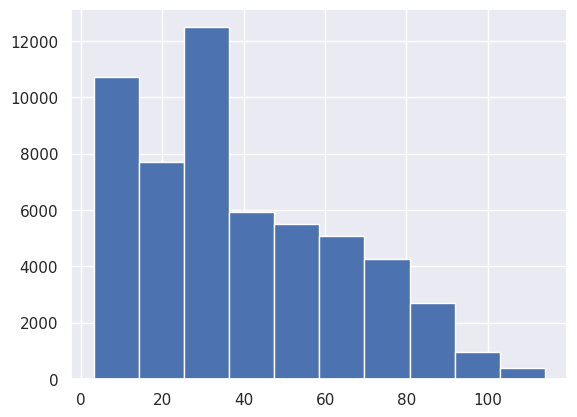

In [21]:
plt.hist(Vs)

In [22]:
grad_Vs = jax.jit(jax.vmap(jax.grad(trained_model.potential, argnums=0)))(zz, argss)

In [23]:
grad_Vs_norms = jnp.linalg.norm(grad_Vs, axis=1)

(array([2.2537e+04, 1.9617e+04, 7.5460e+03, 3.0240e+03, 1.6960e+03,
        8.2800e+02, 3.4700e+02, 1.0200e+02, 2.6000e+01, 2.0000e+00]),
 array([ 0.21790051,  4.94564438,  9.67338753, 14.40113163, 19.12887573,
        23.85661888, 28.58436394, 33.31210327, 38.03984833, 42.76759338,
        47.49533463]),
 <BarContainer object of 10 artists>)

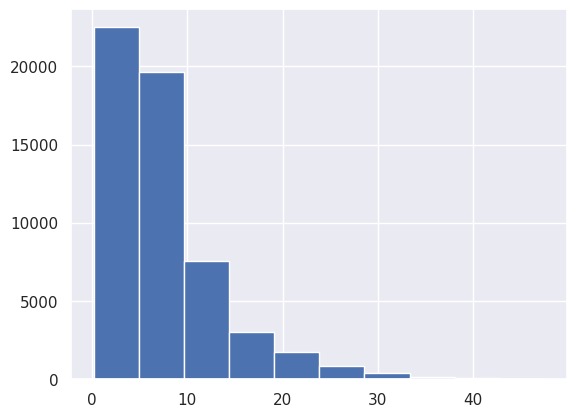

In [24]:
plt.hist(grad_Vs_norms)

<Axes: >

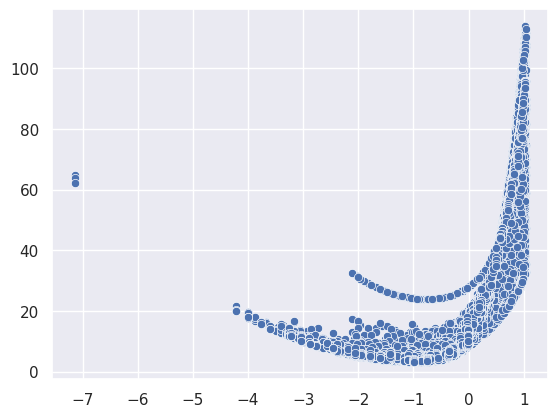

In [25]:
sns.scatterplot(x=argss[:, 1], y=Vs)

<Axes: >

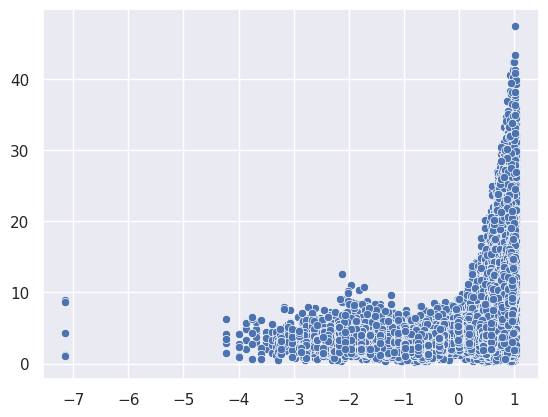

In [26]:
sns.scatterplot(x=argss[:, 1], y=grad_Vs_norms)

### Check the size of M

In [27]:
Ms = jax.jit(jax.vmap(trained_model.dissipation))(zz, argss)

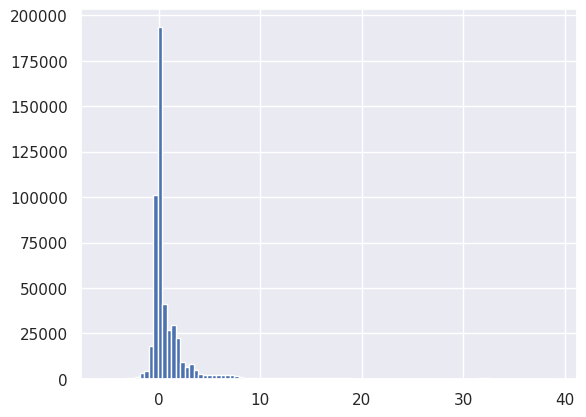

In [28]:
plt.hist(Ms.ravel(), bins=100);

In [29]:
Ms_norms = jnp.linalg.norm(Ms, axis=(1, 2))

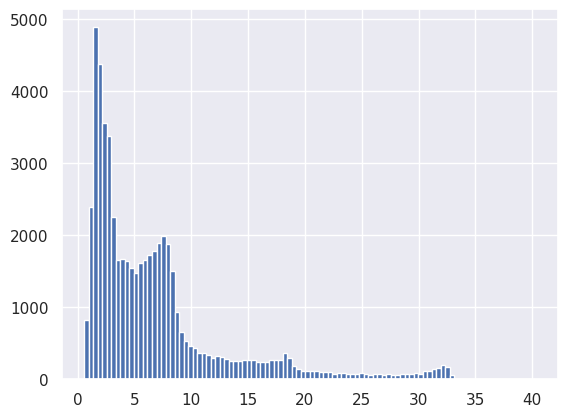

In [30]:
plt.hist(Ms_norms, bins=100);

<Axes: >

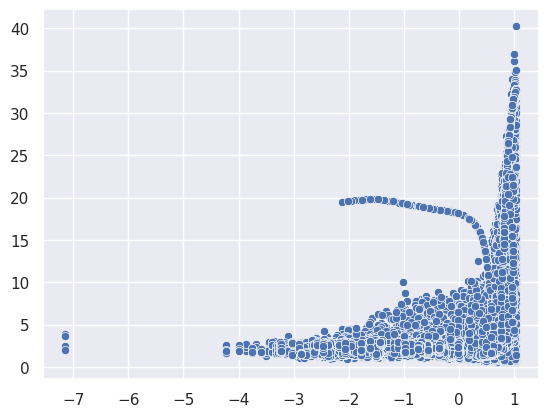

In [31]:
sns.scatterplot(x=argss[:, 1], y=Ms_norms)

### Check the size of W

In [32]:
Ws = jax.jit(jax.vmap(trained_model.conservation))(zz, argss)

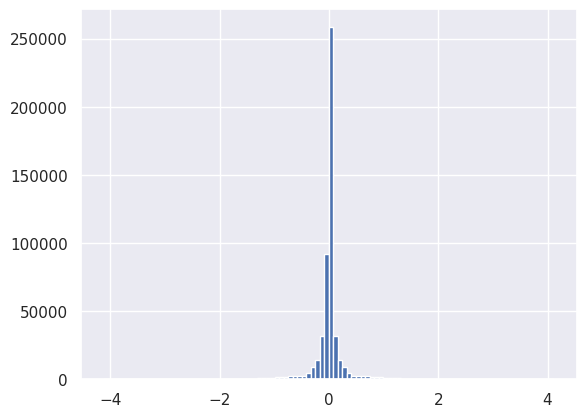

In [33]:
plt.hist(Ws.ravel(), bins=100);

In [34]:
Ws_norms = jnp.linalg.norm(Ws, axis=(1, 2))

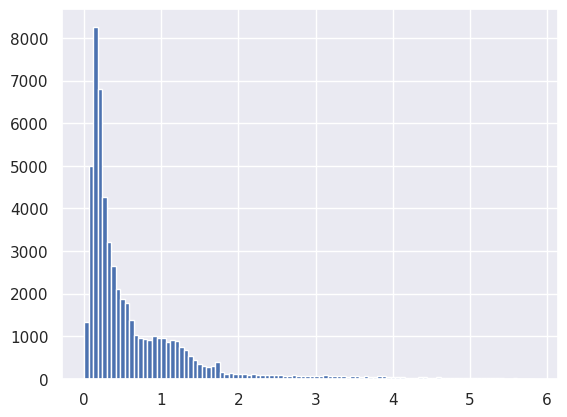

In [35]:
plt.hist(Ws_norms, bins=100);

<Axes: >

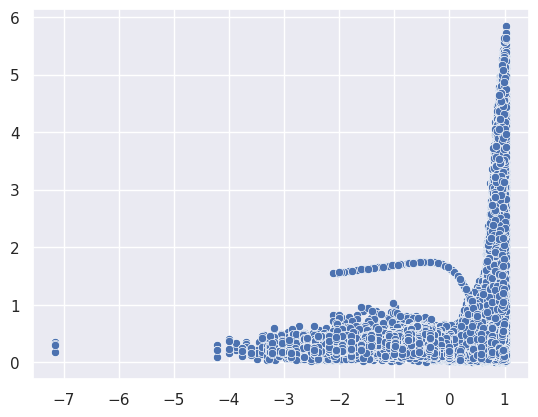

In [36]:
sns.scatterplot(x=argss[:, 1], y=Ws_norms)

# Comparisons

In [68]:
# Load multiple models for comparison
output_paths = [
    # "outputs/2025_09_20-16_07_22",   # Fully symmetrised PCA and model, log-scale, extra data, run 1
    # "outputs/2025_09_21-10_13_21",   # Fully symmetrised PCA and model, log-scale, extra data, run 2
    # "outputs/2025_09_21-10_15_54",   # Fully symmetrised PCA and model, log-scale, extra data, run 3
    # "outputs/2025_09_21-10_14_45",   # Fully symmetrised PCA and model, log-scale, extra data, run 4
    # "outputs/2025_09_21-10_16_23",   # Fully symmetrised PCA and model, log-scale, extra data, run 5
    # "outputs/2025_09_25-20_02_34",  # New everything, no norm constraint, regularisation, run1
    # "outputs/2025_09_26-21_42_14",
    # "outputs/2025_09_26-21_42_02",
    "outputs/2025_09_28-21_33_12",  # new everything, no norm constraint, regularisation (1e-3), run 1
    "outputs/2025_09_28-21_33_17",
]

models = []
configs = []

for path in output_paths:
    config = OmegaConf.load(os.path.join(path, ".hydra/config.yaml"))
    model_template = build_model(config)
    trained_model = eqx.tree_deserialise_leaves(os.path.join(path, "model.eqx"), model_template)
    models.append(trained_model)
    configs.append(config)

print(f"Loaded {len(models)} models for comparison")

Loaded 2 models for comparison


In [69]:
# Cell to compare configs and print differing entries
import pprint

def dict_diff(dicts, path=""):
    """
    Recursively find and return differences in a list of dicts.
    Returns a dict of {key_path: [values from each dict]} for differing keys.
    """
    if not dicts:
        return {}

    # Check if all values are the same
    first = dicts[0]
    if all(d == first for d in dicts):
        return {}

    differences = {}
    all_keys = set()
    for d in dicts:
        if isinstance(d, dict):
            all_keys.update(d.keys())

    for key in all_keys:
        values = []
        for d in dicts:
            if isinstance(d, dict) and key in d:
                values.append(d[key])
            else:
                values.append(None)  # Key missing in some dicts

        # Check if values differ
        if len(set(str(v) for v in values)) > 1:  # Use str to handle non-hashable types
            sub_path = f"{path}.{key}" if path else key
            if all(isinstance(v, dict) for v in values if v is not None):
                # Recurse for nested dicts
                sub_diff = dict_diff(values, sub_path)
                differences.update(sub_diff)
            else:
                differences[sub_path] = values

    return differences

# Convert OmegaConf configs to dicts
config_dicts = [OmegaConf.to_container(config, resolve=True) for config in configs]

# Compute differences
diffs = dict_diff(config_dicts)

if diffs:
    print("Differing entries among configs:")
    for key, values in diffs.items():
        print(f"\nKey: {key}")
        for i, val in enumerate(values):
            print(f"  Config {i+1}: {pprint.pformat(val)}")
else:
    print("No differences found among configs (all identical).")

Differing entries among configs:

Key: model.seed
  Config 1: 1111
  Config 2: 2222


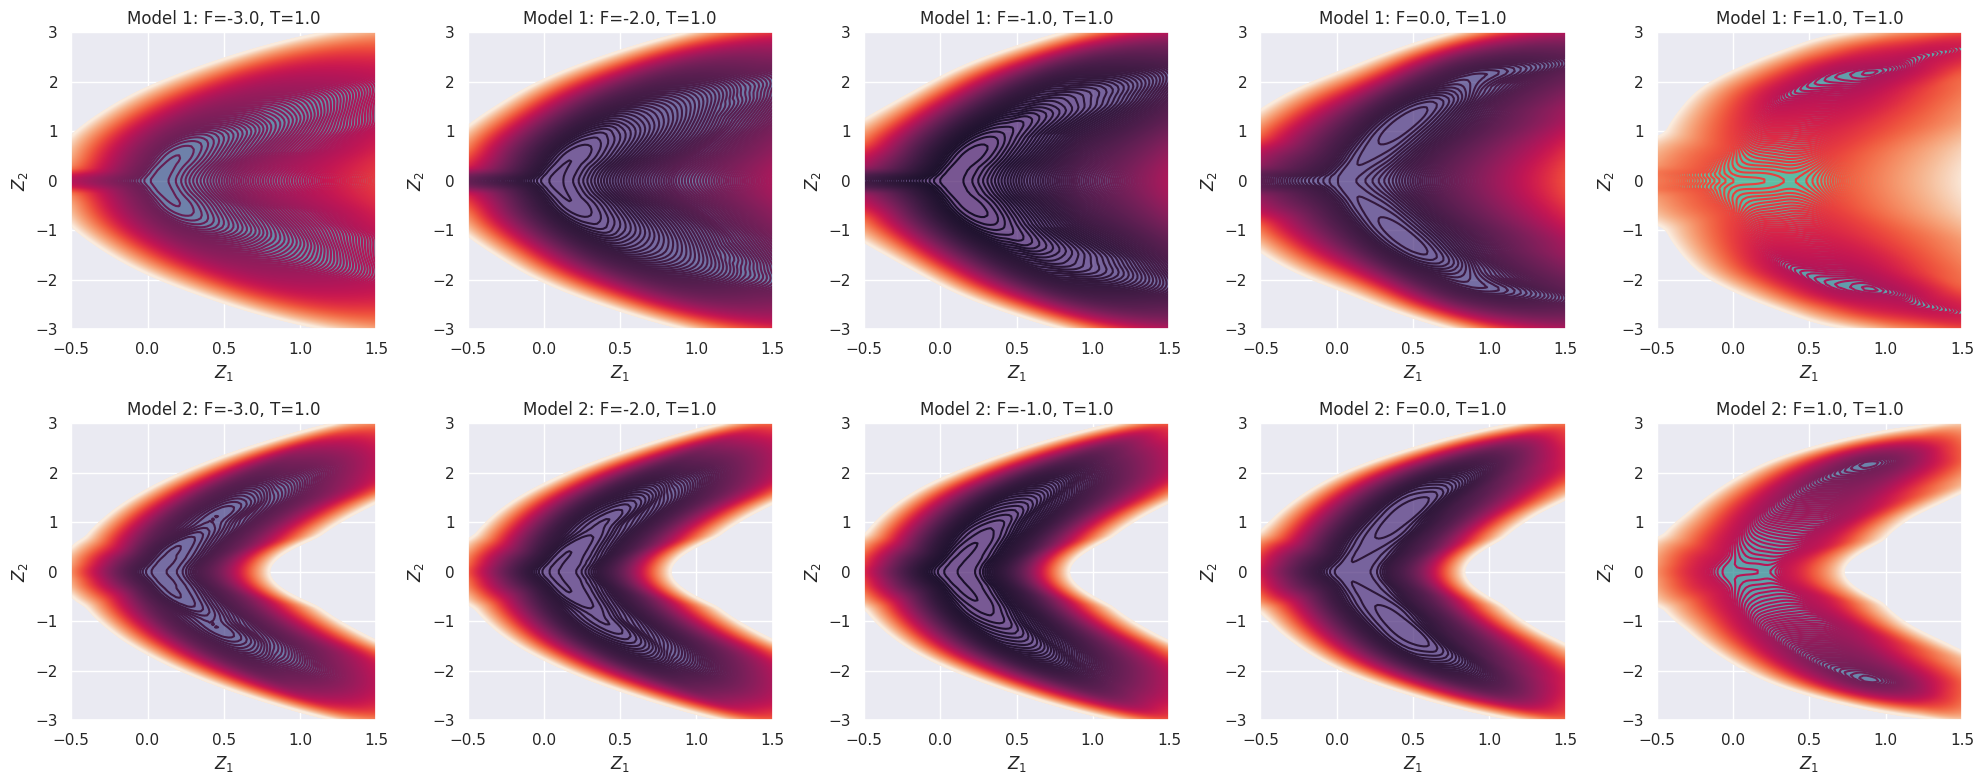

In [70]:
# Contour plots at different F values for each model (T=1.0)

T_fixed = 1.0
F_values_contour = [-3.0, -2, -1, 0., 1.0]  # Select key F values
# F_values_contour = [0.0, 2.0, 5.0, 8.0, 10.0]  # Select key F values

# Create subplots: rows for models, columns for F values
fig, axes = plt.subplots(len(models), len(F_values_contour), figsize=(20, 4 * len(models)))

for i, model in enumerate(models):
    for j, F in enumerate(F_values_contour):
        # Define model-specific potential function
        @jax.jit
        def V_model(z1, z2, z3, T, F):
            args = jnp.array([T, F])
            coords = jnp.array([z1, z2, z3])
            return model.potential(coords, args)

        @jax.jit
        def V_12_model(z1, z2, T, F):
            z3_test_range = jnp.linspace(z3_min, z3_max, num_samples_aux_dimension)
            return jnp.min(jax.vmap(V_model, (None, None, 0, None, None))(z1, z2, z3_test_range, T, F))

        # Get the Z1, Z2 meshgrid and V12_grid values
        z1_range = jnp.linspace(z1_min, z1_max, num_grid)
        z2_range = jnp.linspace(z2_min, z2_max, num_grid)
        Z1, Z2 = jnp.meshgrid(z1_range, z2_range)
        V12_grid = jax.vmap(V_12_model, in_axes=(0, 0, None, None))(Z1.ravel(), Z2.ravel(), T_fixed, F).reshape(Z1.shape)

        # Create contour plot
        ax = axes[i, j] if len(models) > 1 else axes[j]
        contour = ax.contour(Z1, Z2, V12_grid, levels=custom_levels)
        contourf = ax.contourf(Z1, Z2, V12_grid, levels=custom_levels, cmap='viridis', alpha=0.7)

        # Add labels and title
        ax.set_xlabel(r'$Z_1$')
        ax.set_ylabel(r'$Z_2$')
        ax.set_title(f'Model {i+1}: F={F:.1f}, T={T_fixed:.1f}')


plt.tight_layout()
plt.show()

# Encoder and Decoders

In [13]:
from generate_reduced_data import load_pca_components

In [21]:
cache_path = config.data.cache_path
pca_filename = config.data.reduction.filename

In [22]:
P, mu, encode, decode, lams = load_pca_components(cache_path, pca_filename)

(-200.0, 200.0)

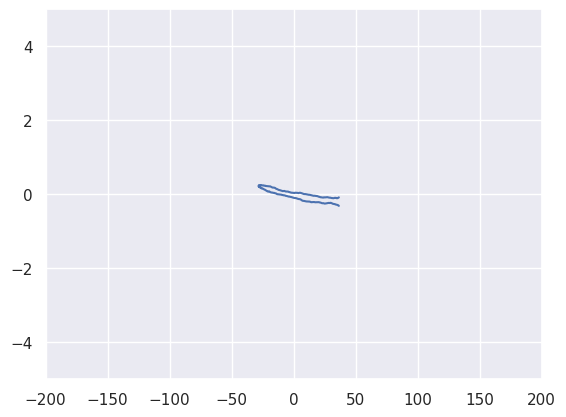

In [67]:
z_coords = np.array([0.0, 5.0])  # z is Nsamples x 2
decoded_coords = decode(z_coords)  # decoded is [Nsamples x 900]
polymer_coords = decoded_coords.reshape(-1, 300, 3)
plt.plot(polymer_coords[0, :, 0], polymer_coords[0, :, 1])
plt.ylim(-5, 5)
plt.xlim(-200, 200)

(-200.0, 200.0)

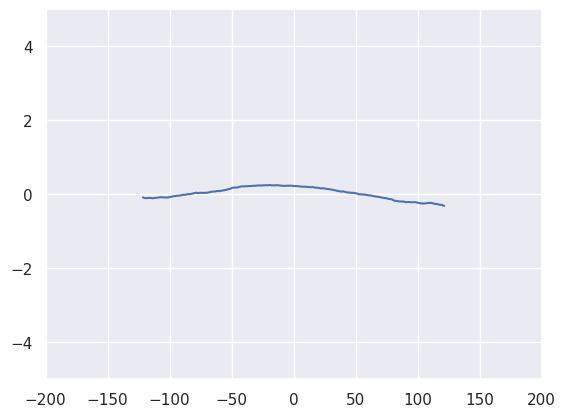

In [69]:
z_coords = np.array([-2.0, 0.0])  # z is Nsamples x 2
decoded_coords = decode(z_coords)  # decoded is [Nsamples x 900]
polymer_coords = decoded_coords.reshape(-1, 300, 3)
plt.plot(polymer_coords[0, :, 0], polymer_coords[0, :, 1])
plt.ylim(-5, 5)
plt.xlim(-200, 200)

## Test symmetries

In [143]:
from generate_reduced_data import make_ops

In [144]:
I, R, Tx, Ty, Tz = make_ops()
# I - identity
# R - head tail reversal
# Tx - reflection in x=0
# Ty - reflection in y=0
# Tz - reflection in z=0

In [145]:
x = np.random.normal(size=(1, 900))

In [146]:
encode(x), encode(x @ R), encode(x @ Tx), encode(x @ Ty), encode(x @ Tz)

(Array([[-0.00038794,  0.00129907]], dtype=float64),
 Array([[0.00038794, 0.00129907]], dtype=float64),
 Array([[ 0.00038794, -0.00129907]], dtype=float64),
 Array([[-0.00038794,  0.00129907]], dtype=float64),
 Array([[-0.00038794,  0.00129907]], dtype=float64))